In [1]:
# pip install scikit-learn torch torchvision matplotlib

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "utils" / "dataloader.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "utils"))

import pandas as pd

import torch
from dataloader import get_dataloaders, load_split

import matplotlib.pyplot as plt

## Load dataset + test/validate/train split
Fashion MNIST splitted 60k samples for training + 10k for testing. 
Split 60k samples into 80% training set / 20% validating set

In [ ]:
(X_train, y_train), (X_validate, y_validate), (X_test, y_test) = load_split("fashion_mnist")

print(f"Raw data type: {X_train.dtype}")
print(f"Raw pixel value range: {X_train.min().item()} to {X_train.max().item()}")

## EDA & Preprocessing

### Check duplicate images
Use Fowler–Noll–Vo hash function (FNV-1a, 32-bit) to detect exact duplicate images

In [4]:
def hash_tensor(tensor: torch.Tensor) -> torch.Tensor:
    tensor_flattened = tensor.view(tensor.size(0), -1)
    FNV_prime = 0x01000193
    FNV_offset_basis = 0x811c9dc5
    hash_values = torch.full((tensor_flattened.size(0),), FNV_offset_basis, dtype=torch.int64)
    for i in range(tensor_flattened.size(1)):
        hash_values = (hash_values ^ tensor_flattened[:, i]) * FNV_prime
    return hash_values

def scale_tensor(tensor: torch.Tensor) -> torch.Tensor:
    tensor = tensor.float()
    return (tensor - tensor.min()) / (tensor.max() - tensor.min())

def z_score_normalize(tensor: torch.Tensor) -> torch.Tensor:
    tensor = tensor.float()
    return (tensor - tensor.mean()) / tensor.std()

In [5]:
SPLITS = {
    "training": (X_train, y_train),
    "validation": (X_validate, y_validate),
    "testing": (X_test, y_test)
}

all_hashes = []

# for split_name, (X_split, y_split) in SPLITS.items():
#     temp_data_loader = DataLoader(TensorDataset(X_split, y_split), batch_size=2048, shuffle=False)
#     for X_batch, y_batch in temp_data_loader:
#         batch_hashes = hash_tensor(X_batch)
#         all_hashes.append(batch_hashes)
        
final_hashes = hash_tensor(torch.cat([X_train, X_validate, X_test], dim=0))

unique_hashes, unique_indices, count_hashes = torch.unique(final_hashes, return_inverse=True, return_counts=True)
print(f"Exist duplicates in the dataset: {torch.any(count_hashes > 1).item()}")

Exist duplicates in the dataset: False


### EDA

In [6]:
X_train = scale_tensor(X_train) # scale pixel values to [0, 1] range
X_validate = scale_tensor(X_validate)
X_test = scale_tensor(X_test)

for split_name, (split_data, split_labels) in SPLITS.items():
    class_counts = {i: count.item() for i, count in enumerate(torch.bincount(split_labels))}
    print(
        f"{split_name.capitalize()} set size: {len(split_data)}\n",
        f"{split_name.capitalize()} set shape: {split_data[0].shape}, {split_data[1].shape}\n",
        f"Class distribution in {split_name} set:\n{class_counts}\n")

Training set size: 48000
 Training set shape: torch.Size([28, 28]), torch.Size([28, 28])
 Class distribution in training set:
{0: 4800, 1: 4800, 2: 4800, 3: 4800, 4: 4800, 5: 4800, 6: 4800, 7: 4800, 8: 4800, 9: 4800}

Validation set size: 12000
 Validation set shape: torch.Size([28, 28]), torch.Size([28, 28])
 Class distribution in validation set:
{0: 1200, 1: 1200, 2: 1200, 3: 1200, 4: 1200, 5: 1200, 6: 1200, 7: 1200, 8: 1200, 9: 1200}

Testing set size: 10000
 Testing set shape: torch.Size([28, 28]), torch.Size([28, 28])
 Class distribution in testing set:
{0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}



In [7]:
BINS = 50
def plot_histogram(df, bins: int | None = BINS):
    plt.figure(figsize=(10, 5))
    plt.hist(df.values, bins=bins, color='blue', alpha=0.7)
    plt.title("Histogram of Pixel Values")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    
def plot_boxplot(df):
    plt.figure(figsize=(10, 5))
    plt.boxplot(df.values, orientation='vertical', patch_artist=True, boxprops=dict(facecolor='lightblue'))
    plt.title("Boxplot of Pixel Values")
    plt.xlabel("Pixel Value")
    plt.grid(axis='x', alpha=0.75)
    plt.show()

def plot_class_images(
    X: torch.Tensor, 
    y: torch.Tensor, 
    class_index: int, 
    num_images: int = 5,
    highlight_lower_threshold: float | None = None,
    highlight_upper_threshold: float | None = None
):
    class_indices = (y == class_index).nonzero(as_tuple=True)[0]
    selected_indices = class_indices[:num_images]
    selected_images = X[selected_indices]
    highlight_mask = None
    if highlight_lower_threshold is not None and highlight_upper_threshold is not None:
        highlight_mask = (
            (selected_images >= highlight_lower_threshold)
            & (selected_images <= highlight_upper_threshold)
        )
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(selected_images[i].squeeze(), cmap='gray')
        if highlight_mask is not None:
            highlighted_pixels = highlight_mask[i].squeeze()
            highlighted_image = selected_images[i].squeeze().clone()
            highlighted_image[~highlighted_pixels] = torch.nan
            highlighted_image[highlighted_pixels] = 0
            plt.imshow(highlighted_image, cmap='YlOrBr', alpha=1)
        plt.axis('off')
    plt.suptitle(f"Class {class_index} Images")
    plt.show()

#### Inspect pixel value distribution in the training set

Pixel statistics summary:
                  0
count  3.763200e+07
mean   2.862529e-01
std    3.531739e-01
min    0.000000e+00
25%    0.000000e+00
50%    0.000000e+00
75%    6.392157e-01
max    1.000000e+00


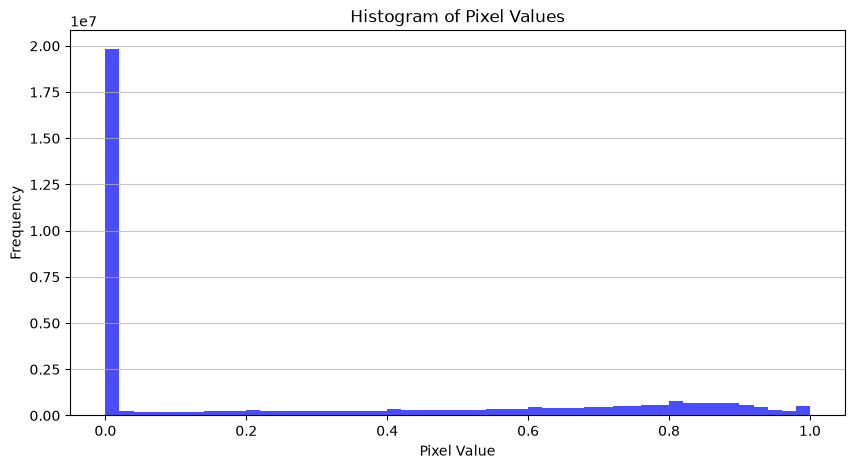

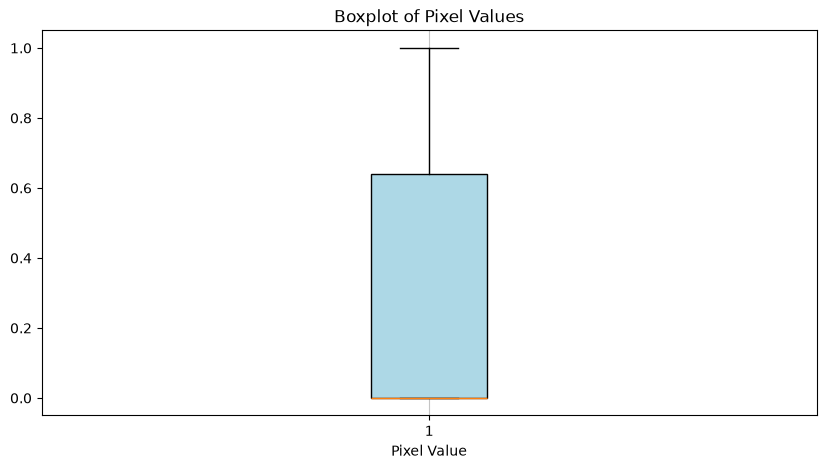

In [8]:
X_df_train = pd.DataFrame(X_train.view(-1).numpy())

print(f"Pixel statistics summary:")
print(X_df_train.describe())

plot_histogram(X_df_train)
plot_boxplot(X_df_train)

#### Inspect non-zero pixel value distribution in the training set

Non-zero pixel statistics summary:
                  0
count  1.873980e+07
mean   5.748336e-01
std    2.908472e-01
min    3.921569e-03
25%    3.450980e-01
50%    6.431373e-01
75%    8.235294e-01
max    1.000000e+00

Top 5 most frequent non-zero pixel values:
(0.0019299999999999999, 0.0238]    1008462
(0.861, 0.88]                       689627
(0.841, 0.861]                      682593
(0.88, 0.9]                         662355
(0.821, 0.841]                      660081
Name: count, dtype: int64


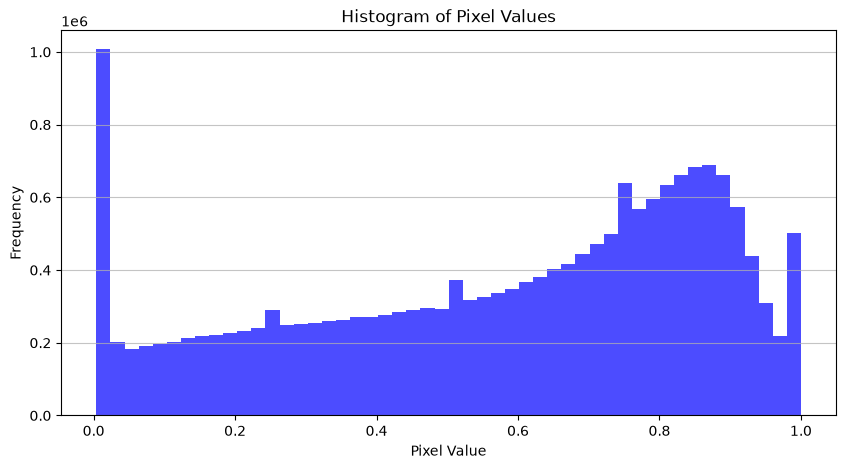

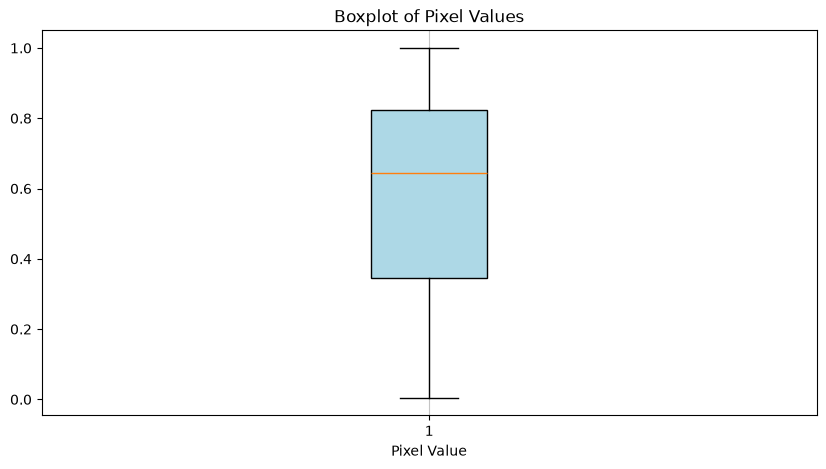

In [9]:
non_zero_pixels = X_df_train.copy()
non_zero_pixels = non_zero_pixels[non_zero_pixels > 0].dropna()

print(f"Non-zero pixel statistics summary:")
print(non_zero_pixels.describe())

print(f"\nTop 5 most frequent non-zero pixel values:")
freq_counts = pd.Series(non_zero_pixels.values.flatten()).value_counts(bins=BINS)
print(freq_counts.head(5))

plot_histogram(non_zero_pixels)
plot_boxplot(non_zero_pixels)

#### Inspecting near-black pixels

Near-black pixel statistics summary:
                  0
count  1.008462e+06
mean   9.618588e-03
std    6.068752e-03
min    3.921569e-03
25%    3.921569e-03
50%    7.843138e-03
75%    1.176471e-02
max    2.352941e-02
Frequency of near-black pixel values:
0.003922    381962
0.007843    229630
0.011765    153729
0.015686    105099
0.019608     77562
0.023529     60480
Name: count, dtype: int64


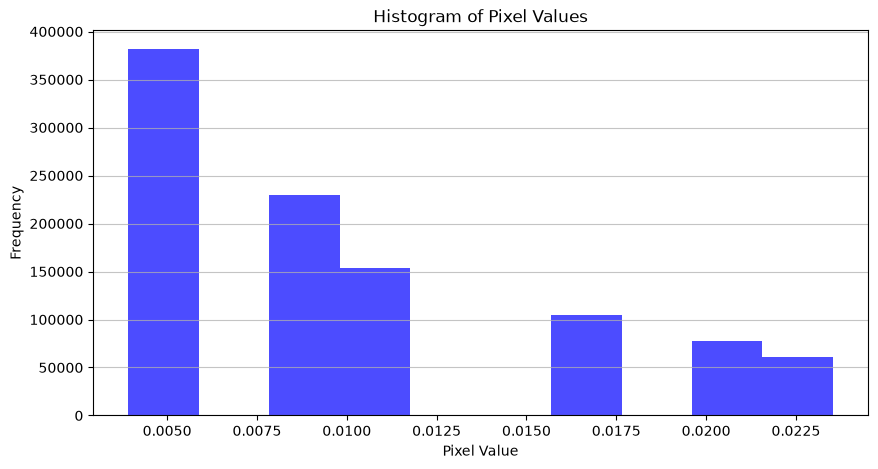

In [10]:
NEAR_BLACK_UPPER_THRESHOLD = 0.0238
near_black_pixels = X_df_train.copy()
near_black_pixels = near_black_pixels[
    near_black_pixels.gt(0) & near_black_pixels.le(NEAR_BLACK_UPPER_THRESHOLD)
].dropna()

print(f"Near-black pixel statistics summary:")
print(near_black_pixels.describe())

print(f"Frequency of near-black pixel values:")
freq_counts = pd.Series(near_black_pixels.values.flatten()).value_counts()

print(freq_counts)
plot_histogram(near_black_pixels, bins=None)

Most images are dominated by pure black background. Non-zero pixel distribution is predominantly  left-skewed but illustrates an abnormally high frequency of "near-black" pixels. These near-black pixels seem to outline the clothing items, but some are randomly scattered fragments. This indicates these pixels might include a mixture of shadow feature and noise.


Visualizing sample images for each class:


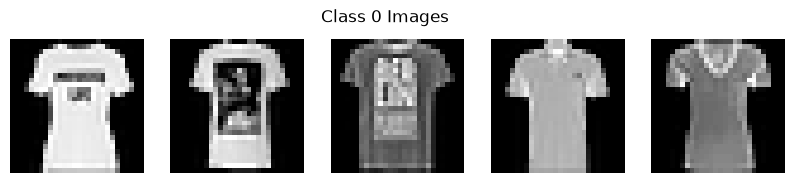

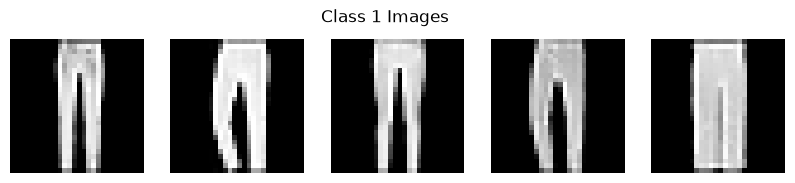

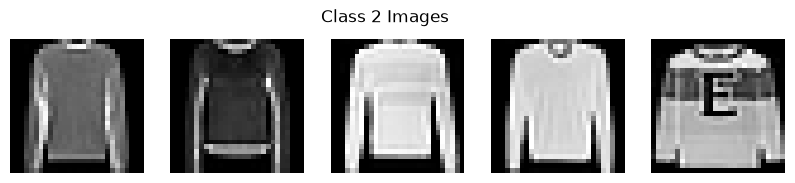

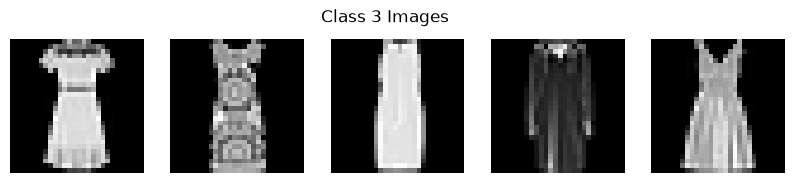

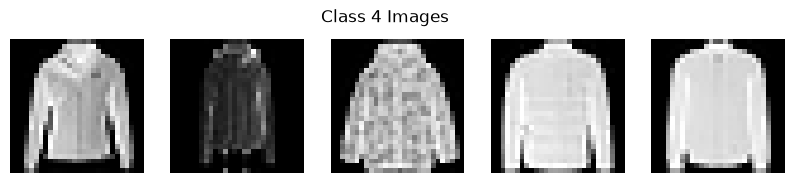

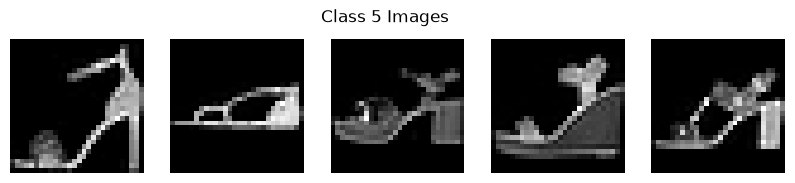

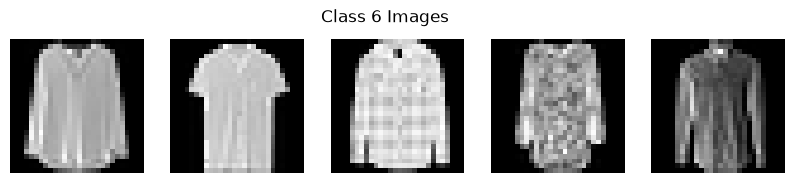

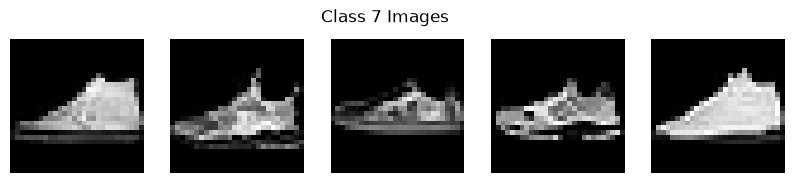

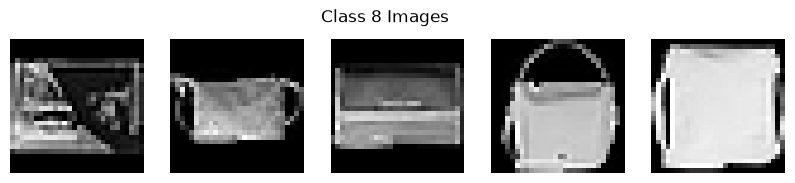

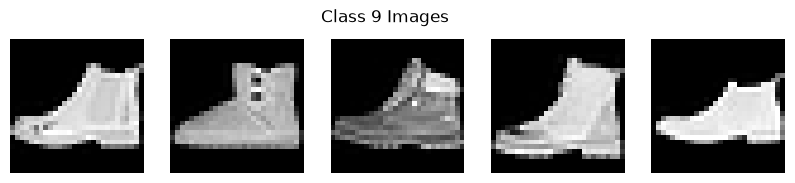

In [11]:
num_classes = 10
images_per_class = 5

print(f"\nVisualizing sample images for each class:")
for label in range(num_classes):
    plot_class_images(X_train, y_train, class_index=label, num_images=images_per_class)


Visualizing sample images for each class with near-black pixels highlighted:


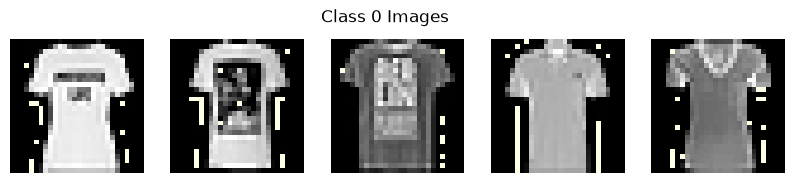

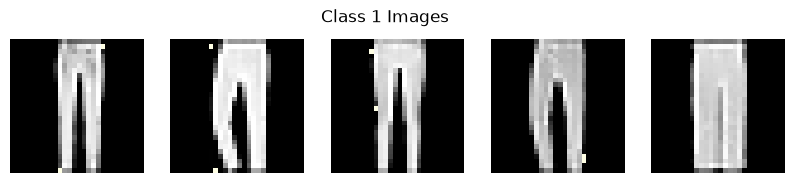

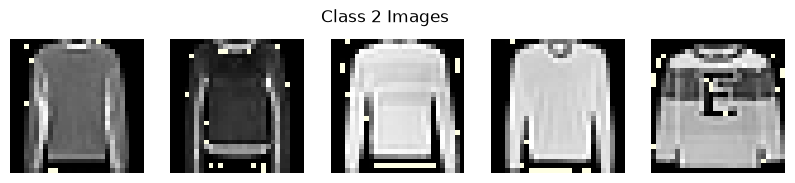

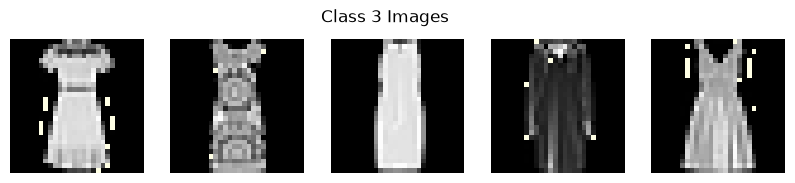

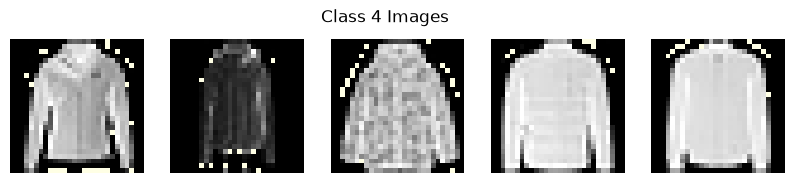

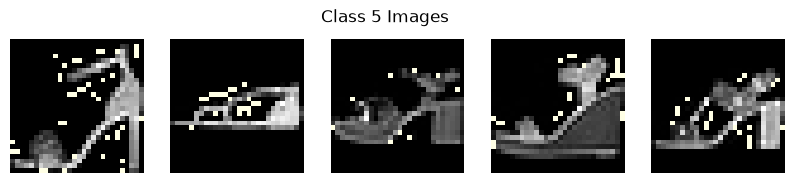

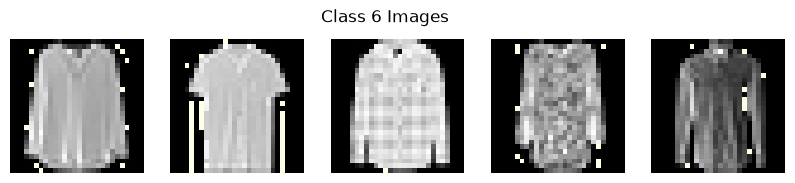

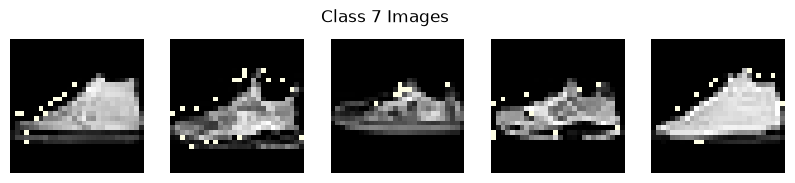

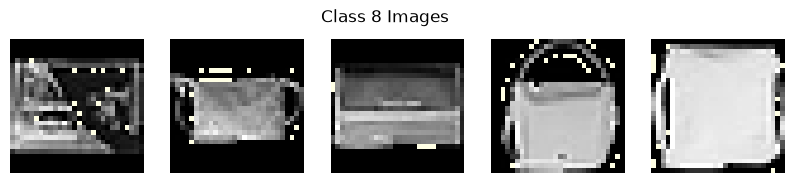

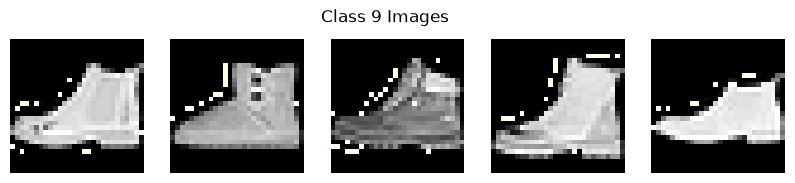

In [12]:
print(f"\nVisualizing sample images for each class with near-black pixels highlighted:")
for class_index in range(num_classes):
    plot_class_images(
        X_train, 
        y_train, 
        class_index, 
        num_images=images_per_class, 
        highlight_lower_threshold=0.003922, 
        highlight_upper_threshold=NEAR_BLACK_UPPER_THRESHOLD
    )

### Augmentation

In [ ]:
# Random horizontal flip for class 5, 7 and 9 (shoes, heels and boots)
shoes_classes = [5, 7, 9]
shoes_mask = torch.isin(y_train, torch.tensor(shoes_classes))
random_mask = torch.rand(X_train.size(0)) < 0.5
flipped_mask = shoes_mask & random_mask

X_train[flipped_mask] = torch.flip(X_train[flipped_mask], dims=[-1])  # Flip horizontally

for class_index in shoes_classes:
    print(f"Class {class_index} samples after augmentation:")
    plot_class_images(X_train, y_train, class_index=class_index, num_images=images_per_class)

In [14]:
# Shadow features are highly irrelevant to classifying clothing items
# Remove near-black pixels from the training set to reduce noise and improve model performance
X_train[X_train <= NEAR_BLACK_UPPER_THRESHOLD] = 0.0

### Dataloader

In [ ]:
train_dataloader, validation_dataloader, test_dataloader = get_dataloaders(
    X_train, y_train, X_validate, y_validate, X_test, y_test
)